# FDSI benchmark: 4. Results

How much online adaptation improves motor unit tracking over no adaptation, across the 100
FDSI recordings (5 subjects × 5 contractions × 4 SNR levels), for each way of tuning it
([2. Search](2_search.ipynb)), and how this version compares with the previous one.

Every unit is a calibrated motor unit matching the ground truth
([1. Calibration](1_calibrate.ipynb)), tracked over the whole recording
([3. Apply](3_apply.ipynb)). This notebook reads only `benchmarks/fdsi/results/`, part of the
repository: it runs anywhere, without the data.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from adapt_decomp.utils.plots import plot_metric_heatmap, plot_phase_bar
from benchmarks.fdsi import pipeline, report

cfg = pipeline.load_config()
results = report.load_results(cfg["version"])
previous = report.load_results(cfg["previous"])
units, calib_units = results["units"], results["calibration_units"]

CONFIGS = list(results["labels"].values())  # no adaptation, then each search's winner
FIXED, ADAPTED = report.FIXED_LABEL, CONFIGS[1:]
CONDITIONS, SNR_LEVELS = cfg["grid"]["conditions"], cfg["grid"]["snr_levels"]
TRIANGULAR = [c for c in CONDITIONS if "triangular" in c]
PALETTE = dict(zip(CONFIGS, sns.color_palette("tab10", len(CONFIGS))))
pd.set_option("display.precision", 2)
print(
    f"{cfg['version']}: {units['recording'].nunique()} recordings, {len(CONFIGS)} configs, "
    f"{len(units)} unit rows (adapt_decomp {results['run']['adapt_decomp']}, "
    f"commit {str(results['run']['commit'])[:7]})"
)

## 1. Gains over no adaptation

RoA of every tracked unit over the whole recording (the calibration window included), per
config, over all 100 recordings, the searches' 3 pool recordings among them (section 3
separates the recordings the searches saw from those they did not).

In [3]:
display(
    report.summary_by_config(units)
    .reindex(CONFIGS)
    .rename(columns={"pct_ge_threshold": "% units RoA ≥ 90"})
)

,n_units,mean,median,std,% units RoA ≥ 90
config,,,,,
No adaptation,785,37.44,35.15,12.55,0.00
"sv_loss, mean",785,83.68,97.16,28.52,72.99
"sv_loss, sum",785,83.08,97.12,28.59,71.34
"Pareto min-sv, mean",785,80.78,95.50,29.60,65.86
"Pareto min-sv, sum",785,82.28,96.77,29.23,70.32
RoA (oracle),785,82.24,96.94,28.65,68.66


### Units per recording

Mean over recordings of the units tracked, those with SIL ≥ 0.9 and those with RoA ≥ 90 %, both
over the whole recording, next to the calibration's own.

In [4]:
columns = ["n_units", "n_sil_ge", "pct_sil_ge", "n_roa_ge"]
per_recording = report.units_per_recording(units, by=["config", "recording"])
calibration = report.units_per_recording(
    calib_units, sil_col="sil_calib", roa_col="roa_calib", by=["recording"]
)[columns].mean()
display(
    pd.concat(
        [
            calibration.rename("Calibration").to_frame().T,
            per_recording.groupby("config", sort=False)[columns].mean().reindex(CONFIGS),
        ]
    ).rename(
        columns={"n_sil_ge": "SIL ≥ 0.9", "pct_sil_ge": "% SIL ≥ 0.9", "n_roa_ge": "RoA ≥ 90 %"}
    )
)

,n_units,SIL ≥ 0.9,% SIL ≥ 0.9,RoA ≥ 90 %
Calibration,7.85,7.85,100.00,7.85
No adaptation,7.85,7.35,96.08,0.00
"sv_loss, mean",7.85,5.19,64.56,5.73
"sv_loss, sum",7.85,5.02,62.22,5.60
"Pareto min-sv, mean",7.85,5.05,62.58,5.17
"Pareto min-sv, sum",7.85,5.13,63.25,5.52
RoA (oracle),7.85,5.39,65.78,5.39


### Paired per-unit gain

Each adapted config against no adaptation, unit by unit (same calibrations, so the same units),
with the Wilcoxon signed-rank test's p-value.

In [5]:
display(report.paired_summary(units, [(FIXED, config) for config in ADAPTED]))

n_units  mean_before  mean_after  \
before        after                                                   
No adaptation sv_loss, mean            785        37.44       83.68   
              sv_loss, sum             785        37.44       83.08   
              Pareto min-sv, mean      785        37.44       80.78   
              Pareto min-sv, sum       785        37.44       82.28   
              RoA (oracle)             785        37.44       82.24   

                                   mean_delta  median_before  median_after  \
before        after                                                          
No adaptation sv_loss, mean             46.24          35.15         97.16   
              sv_loss, sum              45.64          35.15         97.12   
              Pareto min-sv, mean       43.34          35.15         95.50   
              Pareto min-sv, sum        44.84          35.15         96.77   
              RoA (oracle)              44.80          35.15         96.94   

                                   median_delta  pct_improved  pct_unchanged  \
before        after                                                            
No adaptation sv_loss, mean               56.07         88.54           0.13   
              sv_loss, sum                55.49         89.04           0.00   
              Pareto min-sv, mean         53.23         86.62           0.13   
              Pareto min-sv, sum          55.39         88.03           0.00   
              RoA (oracle)                54.09         88.92           0.25   

                                   pct_worse  wilcoxon_p  
before        after                                       
No adaptation sv_loss, mean            11.34   2.37e-120  
              sv_loss, sum             10.96   2.95e-120  
              Pareto min-sv, mean      13.25   2.93e-117  
              Pareto min-sv, sum       11.97   7.03e-119  
              RoA (oracle)             10.83   4.04e-120

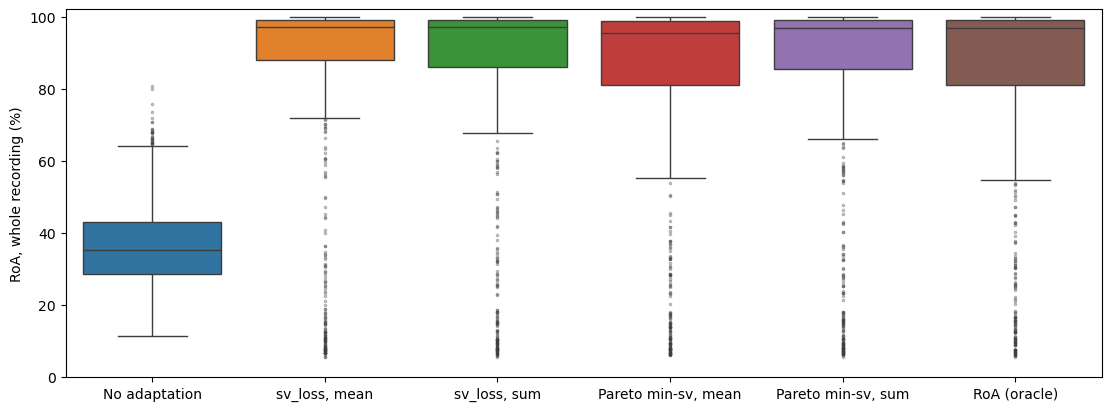

In [6]:
fig, ax = plt.subplots(figsize=(11, 4), layout="constrained")
sns.boxplot(
    data=units,
    x="config",
    y=report.ROA_PCT,
    order=CONFIGS,
    hue="config",
    palette=PALETTE,
    legend=False,
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
    ax=ax,
)
ax.set(xlabel="", ylabel="RoA, whole recording (%)", ylim=(0, 102))
plt.show()

## 2. Across contractions and SNR

Mean RoA over the whole recording (top) and the share of units at or above 90 % (bottom), per
contraction and SNR.

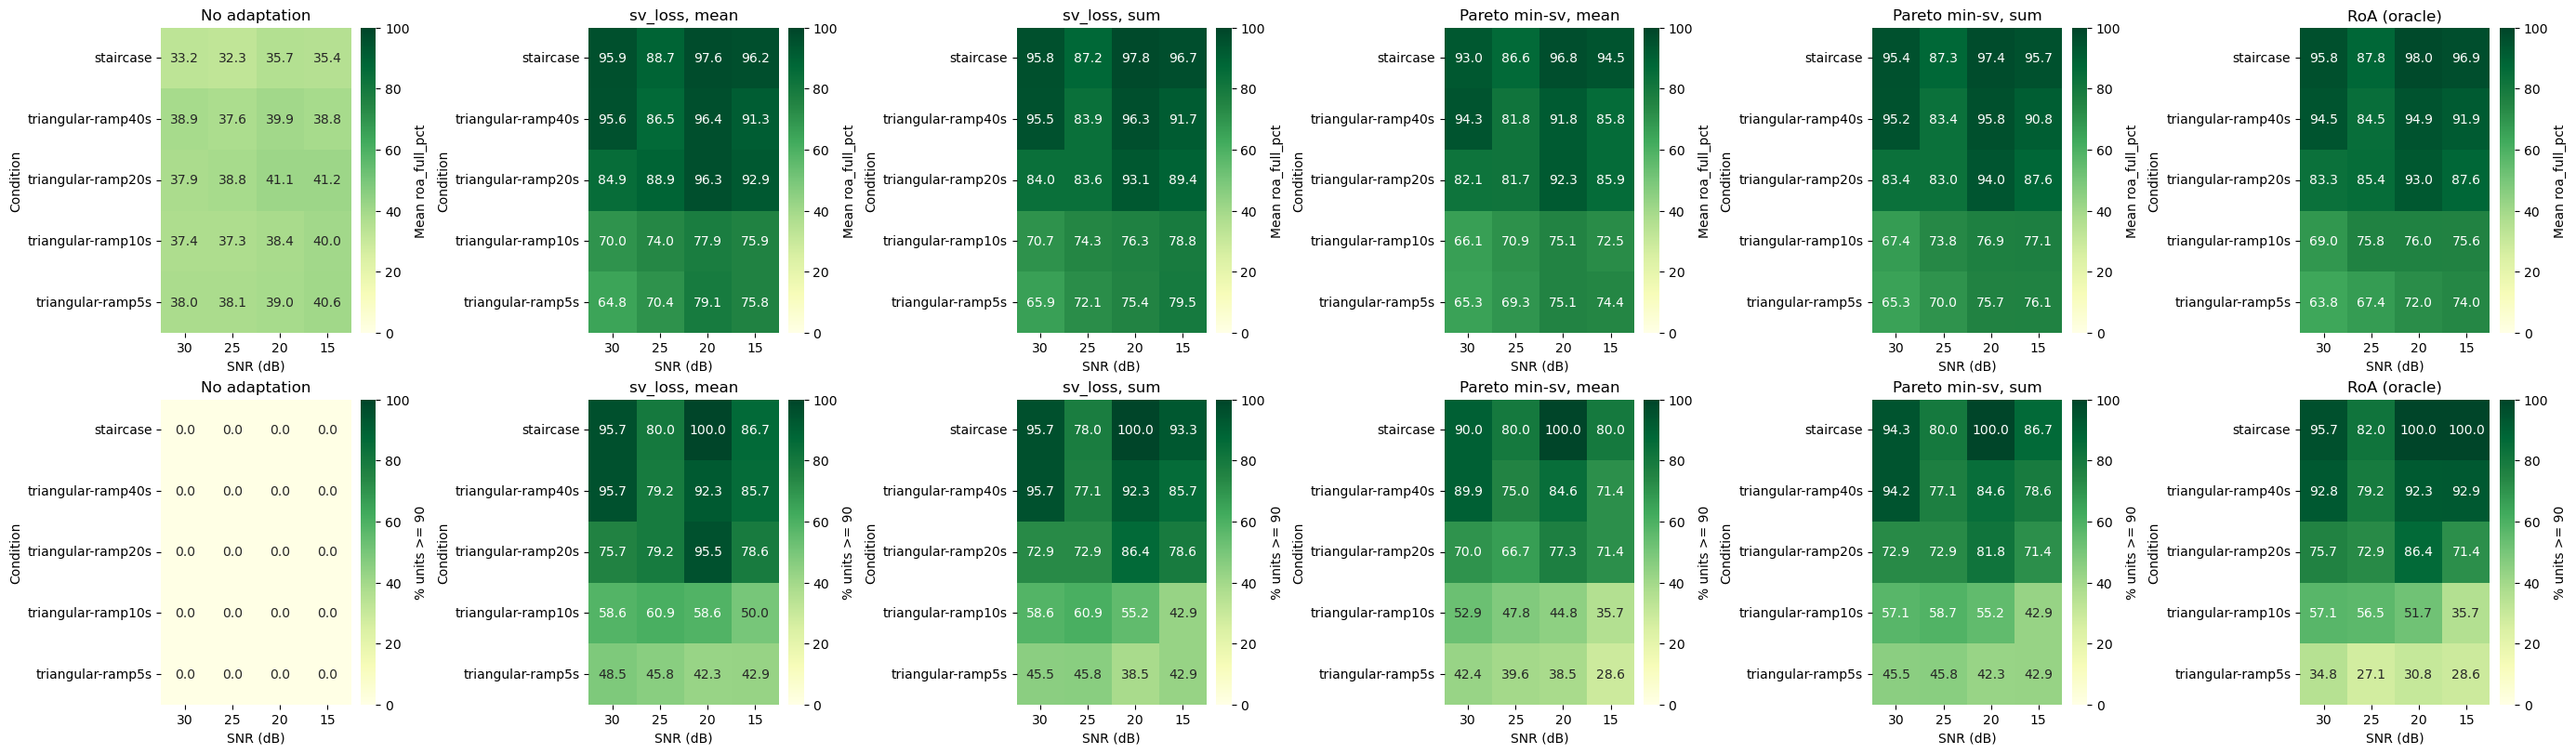

In [7]:
fig, axs = plt.subplots(2, len(CONFIGS), figsize=(4.6 * len(CONFIGS), 8), layout="constrained")
plot_metric_heatmap(
    units, report.ROA_PCT, CONFIGS, CONDITIONS, SNR_LEVELS, vmin=0, vmax=100, axs=axs[0]
)
plot_metric_heatmap(
    units,
    report.ROA_PCT,
    CONFIGS,
    CONDITIONS,
    SNR_LEVELS,
    agg="pct_ge_threshold",
    threshold=90,
    vmin=0,
    vmax=100,
    axs=axs[1],
)
plt.show()

Gain over no adaptation, unit by unit, averaged per contraction and SNR.

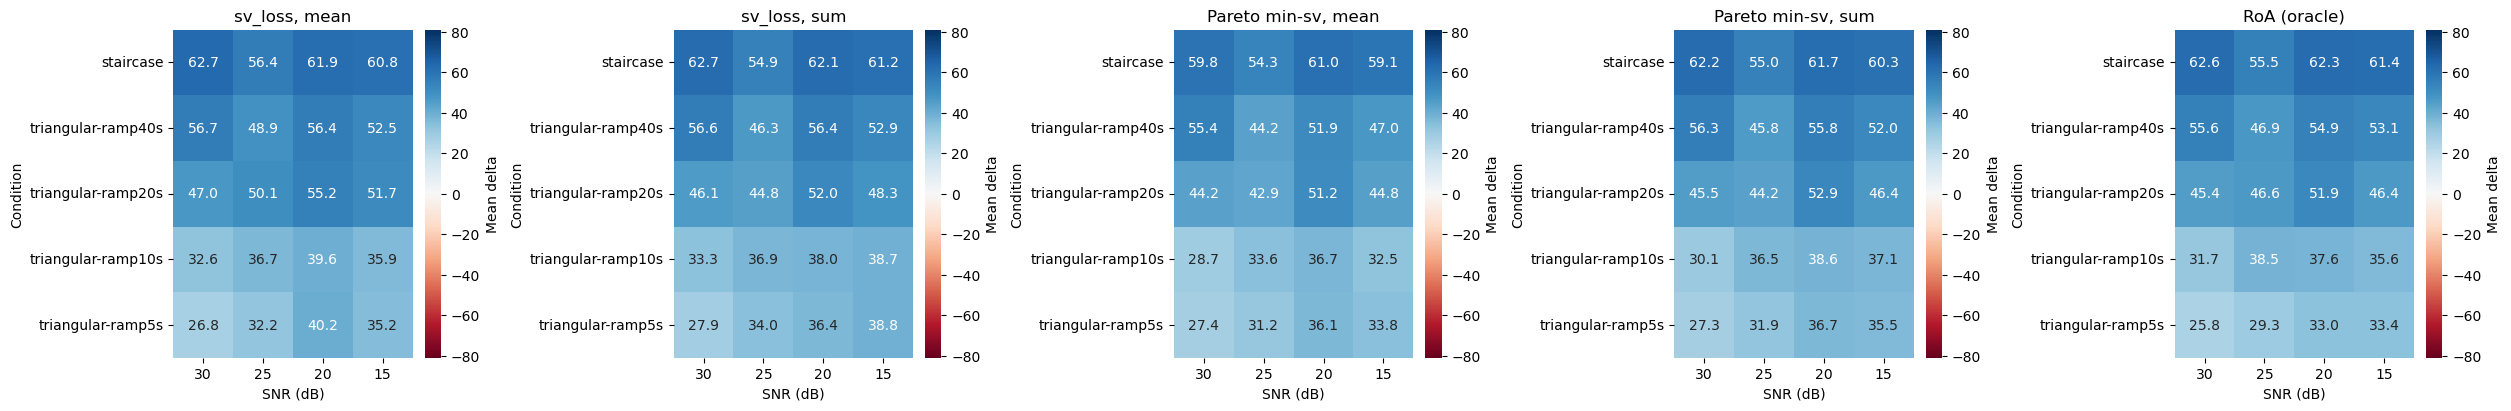

In [8]:
delta = report.heatmap_delta(units, FIXED)
limit = delta["delta"].abs().max()
plot_metric_heatmap(
    delta, "delta", ADAPTED, CONDITIONS, SNR_LEVELS, vmin=-limit, vmax=limit, cmap="RdBu", center=0
)
plt.show()

## 3. Pool and held-out recordings

Every search tuned its parameters on the same pool: subject 1 at 30 dB, in the 40, 10 and 5 s
triangular ramps. So each recording is in one of three groups:

- **pool recordings**: those 3 recordings, the only data the searches saw;
- **pool conditions, other recordings**: the same three ramps on the other subjects and SNR
  levels (57 recordings), a contraction the searches saw but other motor units and noise;
- **held-out conditions**: the staircase and the 20 s triangular ramp, on every subject and SNR
  level (40 recordings), contractions no search saw.

The last two groups show how well each config generalises beyond the recordings it was tuned
on.

In [9]:
splits = list(report.SPLITS)
display(
    units[units["config"] == FIXED]
    .groupby("split")
    .agg(recordings=("recording", "nunique"), units=("unit", "size"))
    .reindex(splits)
    .T
)
display(
    units.pivot_table(
        index="config", columns="split", values=report.ROA_PCT, aggfunc="mean"
    ).reindex(index=CONFIGS, columns=splits)
)

split,pool recordings,"pool conditions, other recordings",held-out conditions
recordings,3,57,40
units,41,429,315


split,pool recordings,"pool conditions, other recordings",held-out conditions
config,,,
No adaptation,37.57,38.35,36.18
"sv_loss, mean",69.16,79.47,91.30
"sv_loss, sum",69.38,79.53,89.70
"Pareto min-sv, mean",66.87,76.90,87.87
"Pareto min-sv, sum",67.15,78.57,89.29
RoA (oracle),72.01,77.64,89.84


## 4. Triangular contractions by phase

Mean RoA in the first isometric hold (the calibration window included), the ramp, and the last
isometric hold, where tracking drifts most without adaptation.

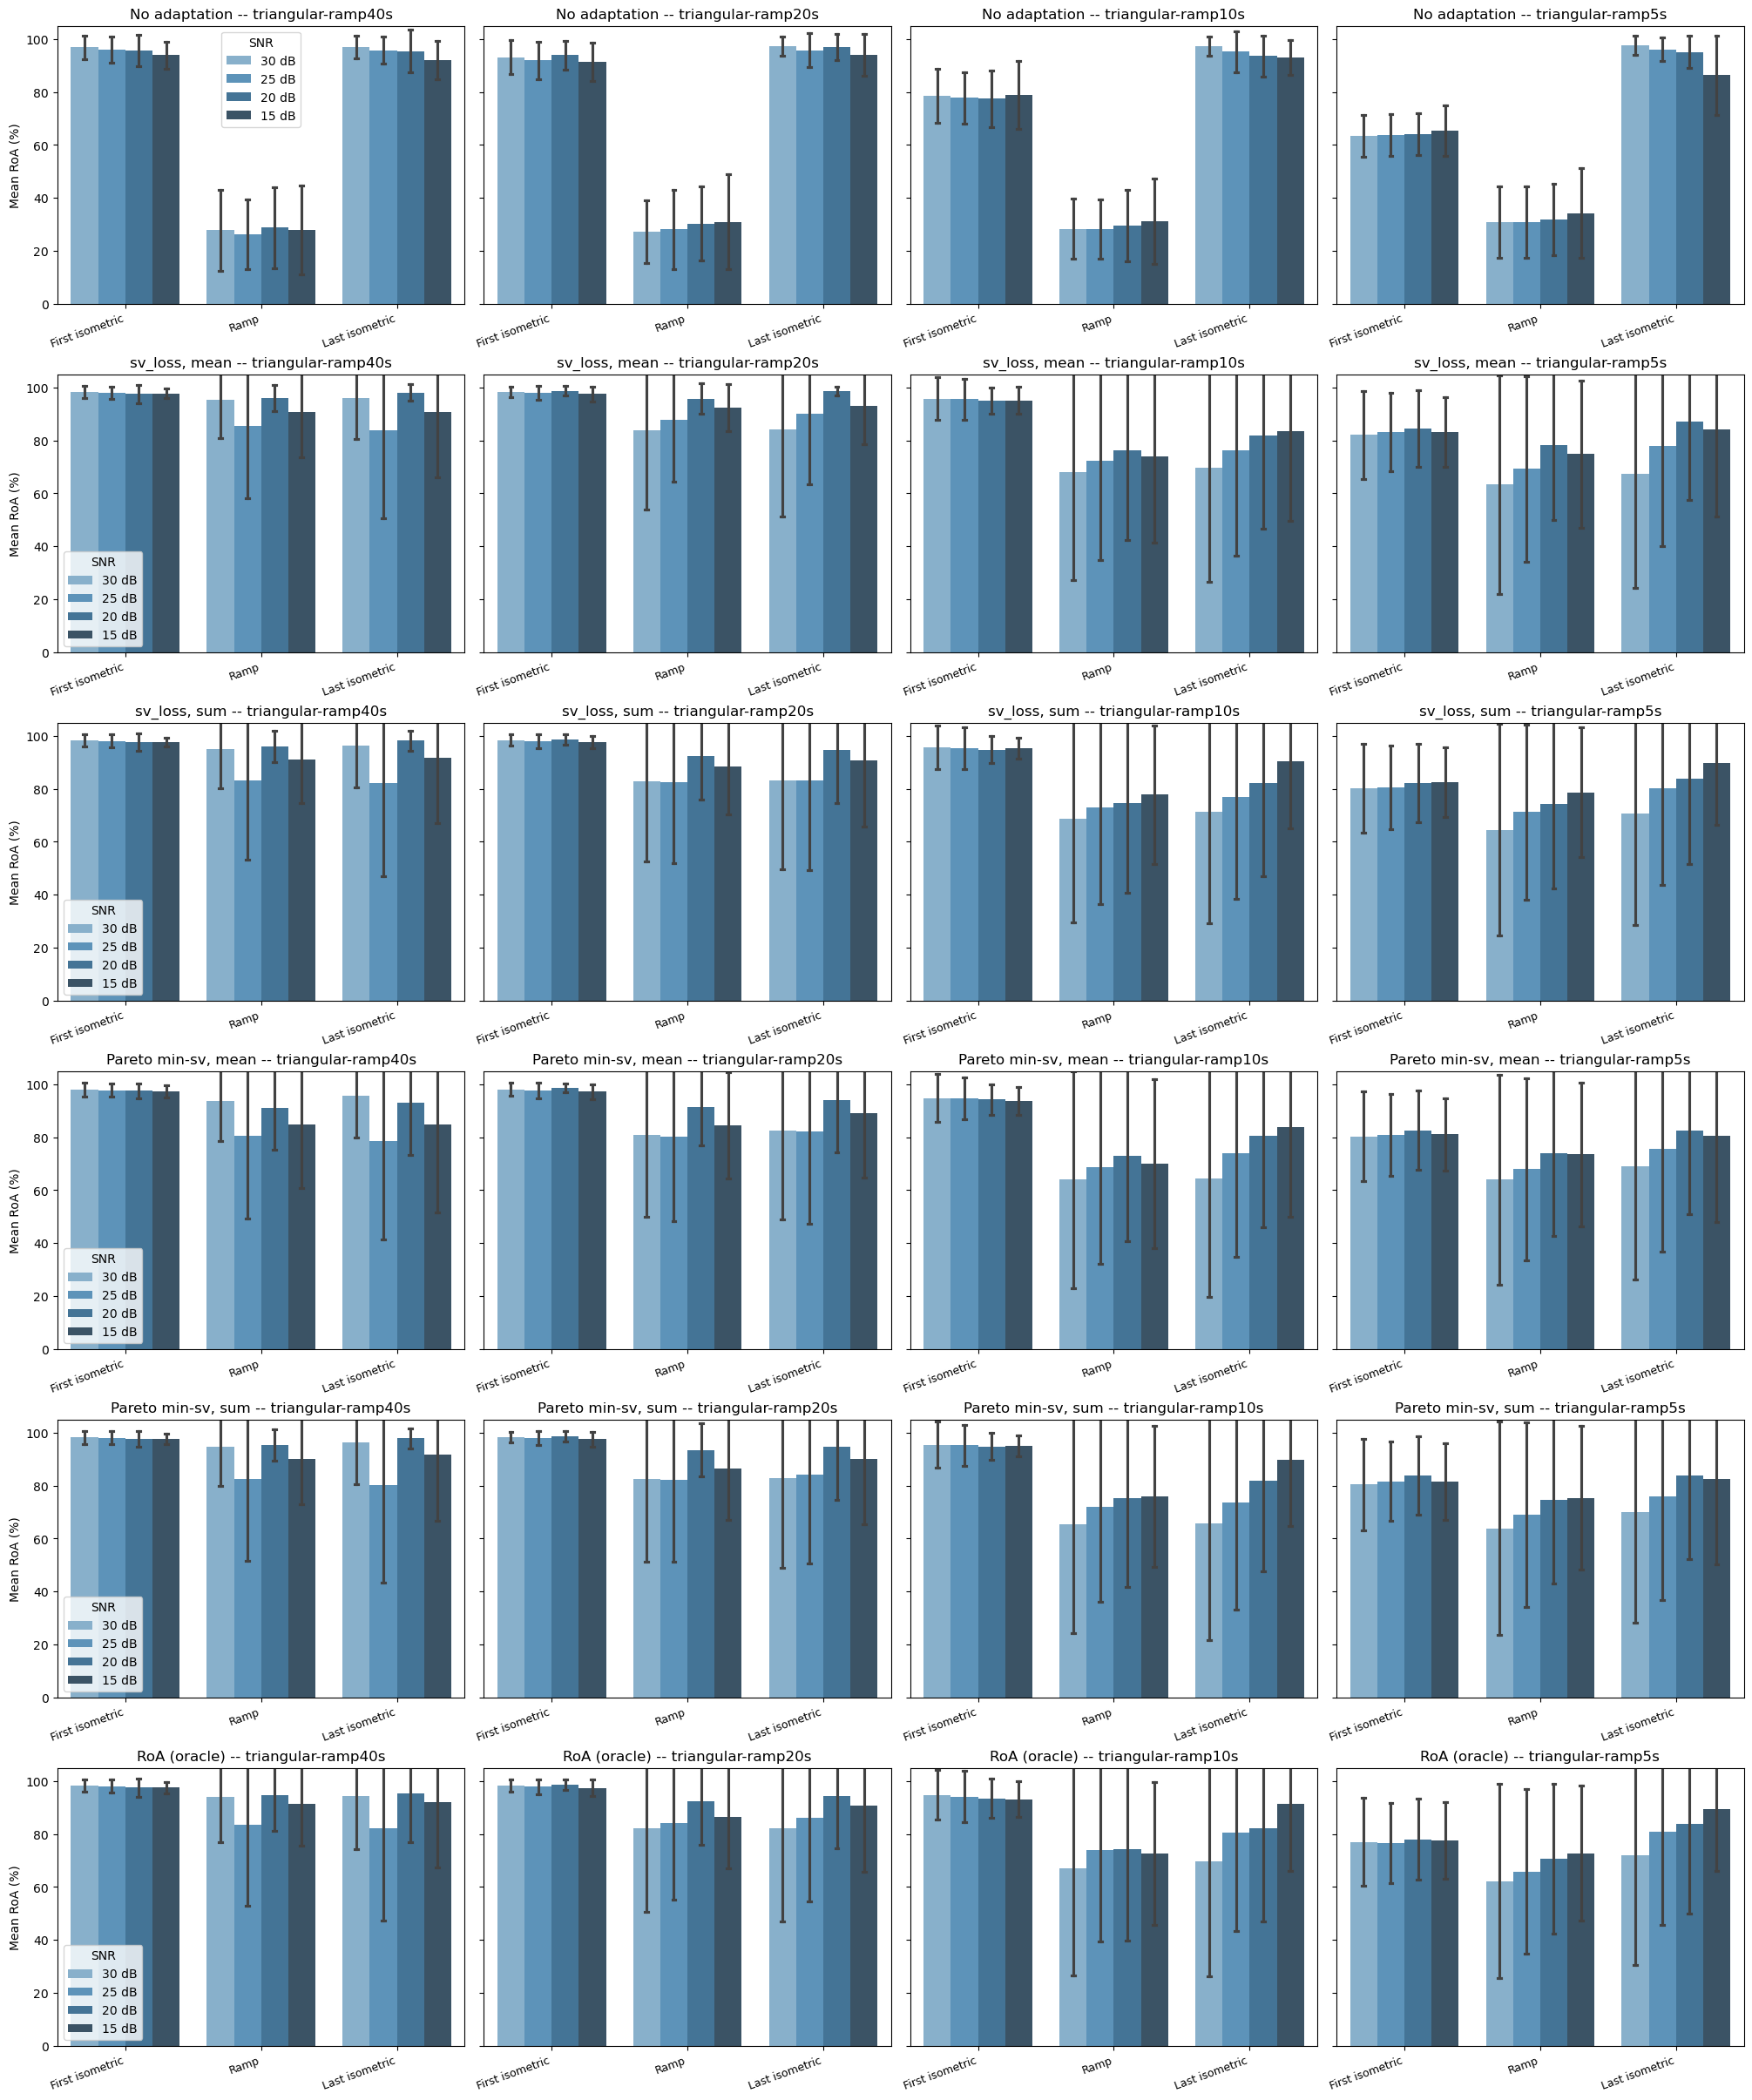

In [10]:
phases = list(report.PHASES.values())
plot_phase_bar(
    report.phase_long(units), CONFIGS, TRIANGULAR, SNR_LEVELS, phases, {p: p for p in phases}
)
plt.show()

## 5. Comparison with the previous version

Every config of both versions over the same 100 recordings: the RoA of every unit over the
whole recording, against the same ground truth and tolerance (both scored by this version's
code, from `results/<version>/units.csv`). Each version calibrated the recordings itself, so
their units differ slightly; units are paired across versions by the simulated motor unit they
track. The previous version's notes:

In [11]:
print(previous["run"].get("notes", ""))
display(
    report.version_summary({cfg["previous"]: previous["units"], cfg["version"]: units}).rename(
        columns={"pct_ge_threshold": "% units RoA ≥ 90"}
    )
)
calibrated = [u[u["config"] == FIXED][["recording", "gt_unit"]] for u in (previous["units"], units)]
print(
    f"Calibrated units: {len(calibrated[0])} in {cfg['previous']}, {len(calibrated[1])} in "
    f"{cfg['version']}, {len(calibrated[0].merge(calibrated[1]))} in both"
)

Adapted each recording from its first sample; searched only wh_learning_rate and sv_learning_rate (centroid_momentum fixed at 0.95) in 50 trials; summed sv_loss over units; applied each search's winner with lr_mode "fixed" and "rel_error".


n_units   mean  median    std  \
version config                                                    
v1.0.0  No adaptation                 768  37.58   34.76  12.59   
        sv_loss                       768  72.69   84.94  28.60   
        Pareto min-sv                 768  79.25   95.03  27.70   
        RoA (oracle)                  768  84.30   96.99  25.24   
        sv_loss, rel_error            768  73.32   87.99  29.05   
        Pareto min-sv, rel_error      768  73.40   87.49  28.55   
        RoA (oracle), rel_error       768  77.90   93.12  28.27   
v1.1.0  No adaptation                 785  37.44   35.15  12.55   
        sv_loss, mean                 785  83.68   97.16  28.52   
        sv_loss, sum                  785  83.08   97.12  28.59   
        Pareto min-sv, mean           785  80.78   95.50  29.60   
        Pareto min-sv, sum            785  82.28   96.77  29.23   
        RoA (oracle)                  785  82.24   96.94  28.65   

                                  % units RoA ≥ 90  
version config                                      
v1.0.0  No adaptation                         0.00  
        sv_loss                              44.27  
        Pareto min-sv                        57.68  
        RoA (oracle)                         68.49  
        sv_loss, rel_error                   47.27  
        Pareto min-sv, rel_error             46.48  
        RoA (oracle), rel_error              55.60  
v1.1.0  No adaptation                         0.00  
        sv_loss, mean                        72.99  
        sv_loss, sum                         71.34  
        Pareto min-sv, mean                  65.86  
        Pareto min-sv, sum                   70.32  
        RoA (oracle)                         68.66

Calibrated units: 768 in v1.0.0, 785 in v1.1.0, 759 in both


Each config of this version against the previous version's best config without ground truth,
unit by unit over the units both versions tracked.

In [12]:
without_gt = [c for c in previous["labels"].values() if "oracle" not in c and c != FIXED]
best_previous = previous["units"].groupby("config")[report.ROA_PCT].mean()[without_gt].idxmax()
before = f"{cfg['previous']}: {best_previous}"
both = pd.concat(
    [
        previous["units"].query("config == @best_previous").assign(config=before),
        units.assign(config=f"{cfg['version']}: " + units["config"]),
    ]
)
pairs = [(before, f"{cfg['version']}: {config}") for config in ADAPTED]
display(report.paired_summary(both, pairs, keys=("recording", "gt_unit")))

n_units  mean_before  \
before                after                                               
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean            759        79.62   
                      v1.1.0: sv_loss, sum             759        79.62   
                      v1.1.0: Pareto min-sv, mean      759        79.62   
                      v1.1.0: Pareto min-sv, sum       759        79.62   
                      v1.1.0: RoA (oracle)             759        79.62   

                                                   mean_after  mean_delta  \
before                after                                                 
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean             84.43        4.81   
                      v1.1.0: sv_loss, sum              83.90        4.29   
                      v1.1.0: Pareto min-sv, mean       81.60        1.98   
                      v1.1.0: Pareto min-sv, sum        83.09        3.47   
                      v1.1.0: RoA (oracle)              82.96        3.34   

                                                   median_before  \
before                after                                        
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean                95.16   
                      v1.1.0: sv_loss, sum                 95.16   
                      v1.1.0: Pareto min-sv, mean          95.16   
                      v1.1.0: Pareto min-sv, sum           95.16   
                      v1.1.0: RoA (oracle)                 95.16   

                                                   median_after  median_delta  \
before                after                                                     
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean               97.27          0.27   
                      v1.1.0: sv_loss, sum                97.25          0.31   
                      v1.1.0: Pareto min-sv, mean         95.83         -0.03   
                      v1.1.0: Pareto min-sv, sum          96.88          0.17   
                      v1.1.0: RoA (oracle)                97.20          0.37   

                                                   pct_improved  \
before                after                                       
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean               45.19   
                      v1.1.0: sv_loss, sum                45.45   
                      v1.1.0: Pareto min-sv, mean         37.15   
                      v1.1.0: Pareto min-sv, sum          41.77   
                      v1.1.0: RoA (oracle)                47.04   

                                                   pct_unchanged  pct_worse  \
before                after                                                   
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean                32.54      22.27   
                      v1.1.0: sv_loss, sum                 34.78      19.76   
                      v1.1.0: Pareto min-sv, mean          25.56      37.29   
                      v1.1.0: Pareto min-sv, sum           32.94      25.30   
                      v1.1.0: RoA (oracle)                 34.65      18.31   

                                                   wilcoxon_p  
before                after                                    
v1.0.0: Pareto min-sv v1.1.0: sv_loss, mean          1.60e-17  
                      v1.1.0: sv_loss, sum           3.10e-21  
                      v1.1.0: Pareto min-sv, mean    4.11e-02  
                      v1.1.0: Pareto min-sv, sum     1.68e-10  
                      v1.1.0: RoA (oracle)           4.90e-24

## Reproduce

These results come from `python -m benchmarks.fdsi collect` after the three stages
(notebooks 1-3, the same CLI, or `bash benchmarks/fdsi/pbs/submit.sh` on a PBS cluster);
`results/<version>/run.yaml` records the adapt_decomp version, the commit and the whole config
that produced them.